In [ ]:
import torch
import torch.nn.functional as F
from math import log10
from skimage.metrics import structural_similarity as ssim
import numpy as np


In [ ]:
!mkdir -p ~/.kaggle


In [ ]:
import json, os

kaggle_creds = {
    "username": "rajakumar1100",
    "key": "KGAT_3f87b6c47db6581c5fd30852be67ceed"
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!pip uninstall -y kaggle
!pip install -q kaggle


Found existing installation: kaggle 2.0.1
Uninstalling kaggle-2.0.1:
  Successfully uninstalled kaggle-2.0.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 8.4 MB/s eta 0:00:00


In [ ]:
!kaggle datasets download -d jessicali9530/celeba-dataset


Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:34<00:00, 15.1MB/s]



In [ ]:
!unzip celeba-dataset.zip -d celeba


Streaming output truncated to the last 5000 lines.
  inflating: celeba/img_align_celeba/img_align_celeba/197605.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197606.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197607.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197608.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197609.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197610.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197611.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197612.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197613.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197614.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197615.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197616.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197617.jpg  
  inflating: celeba/img_align_celeba/img_align_celeba/197618.jpg  
  inflating

In [ ]:
!ls celeba/img_align_celeba/img_align_celeba | head


000001.jpg
000002.jpg
000003.jpg
000004.jpg
000005.jpg
000006.jpg
000007.jpg
000008.jpg
000009.jpg
000010.jpg


In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

class CelebAFSRDataset(Dataset):
    def __init__(self, img_dir, limit=None):
        self.img_dir = img_dir
        self.imgs = sorted(os.listdir(img_dir))
        if limit:
            self.imgs = self.imgs[:limit]

        self.hr_transform = T.Compose([
            T.CenterCrop(178),
            T.Resize((128, 128)),
            T.ToTensor()
        ])

        self.lr_transform = T.Resize(
            (16, 16),
            interpolation=T.InterpolationMode.BICUBIC
        )

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.imgs[idx])).convert("RGB")
        hr = self.hr_transform(img)
        lr = self.lr_transform(hr)
        return lr, hr


In [ ]:
from torch.utils.data import DataLoader

train_dataset = CelebAFSRDataset(
    "celeba/img_align_celeba/img_align_celeba",
    limit=18000  # paper uses 18k
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


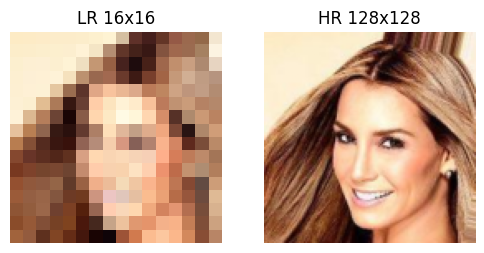

In [ ]:
import matplotlib.pyplot as plt

lr, hr = train_dataset[0]

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(lr.permute(1,2,0))
plt.title("LR 16x16")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hr.permute(1,2,0))
plt.title("HR 128x128")
plt.axis("off")
plt.show()


In [ ]:
import torch
import torch.nn as nn

class CTCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_in = nn.Conv2d(3, 64, 3, 1, 1)
        self.conv_out = nn.Conv2d(64, 3, 3, 1, 1)

    def forward(self, x):
        feat = self.conv_in(x)
        out = self.conv_out(feat)
        return x + out


In [ ]:
x = torch.randn(1,3,16,16)
model = CTCNet()
y = model(x)
print(y.shape)  # should be [1,3,16,16]


torch.Size([1, 3, 16, 16])


In [ ]:
import torch.optim as optim
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CTCNet().to(device)

optimizer = optim.Adam(model.parameters(), lr=2e-4, betas=(0.9, 0.99))

for epoch in range(1):
    for lr, hr in train_loader:
        lr, hr = lr.to(device), hr.to(device)

        sr = model(lr)
        sr_up = F.interpolate(sr, size=(128,128), mode="bicubic")

        loss = F.l1_loss(sr_up, hr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print("Loss:", loss.item())
        break


Loss: 0.20618830621242523


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(self.avg_pool(x))


In [ ]:
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        attn = torch.cat([avg, mx], dim=1)
        return x * self.sigmoid(self.conv(attn))


In [ ]:
class AFDU(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.reduce = nn.Conv2d(channels, channels // 2, 3, 1, 1)
        self.expand = nn.Conv2d(channels // 2, channels, 3, 1, 1)
        self.fuse = nn.Conv2d(channels * 2, channels, 1)

    def forward(self, x):
        r = F.relu(self.reduce(x))
        e = F.relu(self.expand(r))
        out = torch.cat([x, e], dim=1)
        return self.fuse(out)


In [ ]:
class FSAU(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.afdu1 = AFDU(channels)

        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

        self.afdu2 = AFDU(channels)

    def forward(self, x):
        residual = x

        x = self.afdu1(x)
        x = self.ca(x)
        x = self.sa(x)
        x = self.afdu2(x)

        return x + residual


In [ ]:
x = torch.randn(1, 64, 32, 32)
fsau = FSAU(64)
y = fsau(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)


Input shape : torch.Size([1, 64, 32, 32])
Output shape: torch.Size([1, 64, 32, 32])


In [ ]:


class MDTA(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.dwconv = nn.Conv2d(
            channels * 3, channels * 3,
            kernel_size=3, padding=1, groups=channels * 3
        )
        self.project_out = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        b, c, h, w = x.shape

        # LayerNorm expects (B,H,W,C)
        x_ln = self.norm(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)

        qkv = self.dwconv(self.qkv(x_ln))
        q, k, v = qkv.chunk(3, dim=1)

        q = q.view(b, c, -1)
        k = k.view(b, c, -1)
        v = v.view(b, c, -1)

        q = torch.nn.functional.normalize(q, dim=-1)
        k = torch.nn.functional.normalize(k, dim=-1)

        attn = torch.matmul(q, k.transpose(-2, -1))
        attn = torch.softmax(attn, dim=-1)

        out = torch.matmul(attn, v)
        out = out.view(b, c, h, w)

        return self.project_out(out)


class GDFN(nn.Module):
    def __init__(self, channels, expansion=2):
        super().__init__()
        hidden = channels * expansion

        self.norm = nn.LayerNorm(channels)
        self.project_in = nn.Conv2d(channels, hidden * 2, 1)
        self.dwconv = nn.Conv2d(
            hidden * 2, hidden * 2,
            kernel_size=3, padding=1, groups=hidden * 2
        )
        self.project_out = nn.Conv2d(hidden, channels, 1)

    def forward(self, x):
        b, c, h, w = x.shape

        x_ln = self.norm(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)

        x_proj = self.dwconv(self.project_in(x_ln))
        x1, x2 = x_proj.chunk(2, dim=1)

        x = torch.nn.functional.gelu(x1) * x2
        return self.project_out(x)


class TransformerBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attn = MDTA(channels)
        self.ffn = GDFN(channels)

    def forward(self, x):
        x = x + self.attn(x)
        x = x + self.ffn(x)
        return x


In [ ]:
x = torch.randn(1, 64, 32, 32)
tb = TransformerBlock(64)
y = tb(x)

print("Input :", x.shape)
print("Output:", y.shape)


Input : torch.Size([1, 64, 32, 32])
Output: torch.Size([1, 64, 32, 32])


Input
 → FSAU        (local facial details)
 → Transformer (global facial structure)
 → Residual


In [ ]:


class LGCM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.fsau = FSAU(channels)
        self.transformer = TransformerBlock(channels)

    def forward(self, x):
        residual = x
        x = self.fsau(x)
        x = self.transformer(x)
        return x + residual


In [ ]:
x = torch.randn(1, 64, 32, 32)
lgcm = LGCM(64)
y = lgcm(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)


Input shape : torch.Size([1, 64, 32, 32])
Output shape: torch.Size([1, 64, 32, 32])


In [ ]:

class EncoderBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.lgcm = LGCM(in_channels)

        self.downsample = nn.Sequential(
            nn.Conv2d(in_channels, in_channels * 2, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(in_channels * 2, in_channels * 2, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x):
        x = self.lgcm(x)
        down = self.downsample(x)
        return x, down


In [ ]:
class Encoder(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()

        self.enc1 = EncoderBlock(base_channels)        # 64 → 128
        self.enc2 = EncoderBlock(base_channels * 2)    # 128 → 256

    def forward(self, x):
        e1, x = self.enc1(x)   
        e2, x = self.enc2(x)   

        return e1, e2, x


In [ ]:
x = torch.randn(1, 64, 16, 16)   
encoder = Encoder(base_channels=64)

e1, e2, bottleneck_feat = encoder(x)

print("e1:", e1.shape)       
print("e2:", e2.shape)        
print("bottleneck_feat:", bottleneck_feat.shape) 

e1: torch.Size([1, 64, 16, 16])
e2: torch.Size([1, 128, 8, 8])
bottleneck_feat: torch.Size([1, 256, 4, 4])


In [ ]:

class FEU(nn.Module):
    def __init__(self, channels):
        super().__init__()

        
        self.branch1 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1)
        )

       
        self.branch2_down = nn.Conv2d(channels, channels, 3, 2, 1)
        self.branch2_up = nn.ConvTranspose2d(
            channels, channels, kernel_size=4, stride=2, padding=1
        )

        # Fusion
        self.fuse = nn.Conv2d(channels * 2, channels, 1)

        # Self-calibration
        self.calibrate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        b1 = self.branch1(x)

        b2 = self.branch2_down(x)
        b2 = self.branch2_up(b2)

        # Ensure size match
        if b2.shape[-2:] != x.shape[-2:]:
            b2 = nn.functional.interpolate(
                b2, size=x.shape[-2:], mode="bilinear", align_corners=False
            )

        fused = torch.cat([b1, b2], dim=1)
        fused = self.fuse(fused)

        scale = self.calibrate(x)
        return fused + x * scale


In [ ]:


class FRM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.fsau = FSAU(channels)
        self.feu = FEU(channels)

    def forward(self, x):
        x = self.fsau(x)
        x = self.feu(x)
        return x


In [ ]:
x = torch.randn(1, 256, 4, 4)
frm = FRM(256)
y = frm(x)

print("Input :", x.shape)
print("Output:", y.shape)


Input : torch.Size([1, 256, 4, 4])
Output: torch.Size([1, 256, 4, 4])


In [ ]:


class Bottleneck(nn.Module):
    def __init__(self, channels, num_frm=4):
        super().__init__()
        self.blocks = nn.Sequential(
            *[FRM(channels) for _ in range(num_frm)]
        )

    def forward(self, x):
        return self.blocks(x)


In [ ]:
x = torch.randn(1, 256, 4, 4)
bn = Bottleneck(256)
y = bn(x)

print(y.shape)


torch.Size([1, 256, 4, 4])


Upsample (transpose conv, ×2 spatial size)
→ LGCM
→ Channels ÷ 2


In [ ]:


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, enc_same_channels, enc_large_channels):
        super().__init__()

        out_channels = in_channels // 2

        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.mffu = MFFU(
            channels=out_channels,
            enc_same_channels=enc_same_channels,
            enc_large_channels=enc_large_channels
        )

        self.lgcm = LGCM(out_channels)

    def forward(self, x, enc_same, enc_large):
        x = self.upsample(x)
        x = self.mffu(x, enc_same, enc_large)
        x = self.lgcm(x)
        return x



In [ ]:


class Decoder(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()

        # Stage 1: 256 → 128, fuse e2 (128) & e1 (64)
        self.dec1 = DecoderBlock(
            in_channels=base_channels * 4,
            enc_same_channels=base_channels * 2,
            enc_large_channels=base_channels
        )

        # Stage 2: 128 → 64, fuse e1 (64) twice
        self.dec2 = DecoderBlock(
            in_channels=base_channels * 2,
            enc_same_channels=base_channels,
            enc_large_channels=base_channels
        )

    def forward(self, x, e2, e1):
        x = self.dec1(x, e2, e1)
        x = self.dec2(x, e1, e1)
        return x



In [ ]:


class MFFU(nn.Module):
    def __init__(self, channels, enc_large_channels, enc_same_channels):
        super().__init__()

        # Project encoder features to same channels as decoder
        self.proj_same = nn.Conv2d(enc_same_channels, channels, 1)
        self.proj_large = nn.Conv2d(enc_large_channels, channels, 1)

        # Fusion
        self.fuse = nn.Conv2d(channels * 3, channels, 1)

        # Channel attention
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 8, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 8, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, dec_feat, enc_same, enc_large):
        # Resize encoder features
        enc_same = F.interpolate(enc_same, size=dec_feat.shape[-2:], mode="bilinear", align_corners=False)
        enc_large = F.interpolate(enc_large, size=dec_feat.shape[-2:], mode="bilinear", align_corners=False)

        # Channel projection
        enc_same = self.proj_same(enc_same)
        enc_large = self.proj_large(enc_large)

        # Fusion
        x = torch.cat([dec_feat, enc_same, enc_large], dim=1)
        x = self.fuse(x)

        # Channel attention
        return x * self.ca(x)


In [ ]:
x = torch.randn(1, 256, 4, 4)
e2 = torch.randn(1, 128, 8, 8) # Add dummy e2
e1 = torch.randn(1, 64, 16, 16) # Add dummy e1
decoder = Decoder(base_channels=64)
y = decoder(x, e2, e1)

print("Decoder output shape:", y.shape)

Decoder output shape: torch.Size([1, 64, 16, 16])


In [ ]:


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, enc_same_channels, enc_large_channels):
        super().__init__()

        out_channels = in_channels // 2

        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.mffu = MFFU(
            channels=out_channels,
            enc_same_channels=enc_same_channels,
            enc_large_channels=enc_large_channels
        )

        self.lgcm = LGCM(out_channels)

    def forward(self, x, enc_same, enc_large):
        x = self.upsample(x)
        x = self.mffu(x, enc_same, enc_large)
        x = self.lgcm(x)
        return x

In [ ]:


class Decoder(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()

        self.dec1 = DecoderBlock(
            in_channels=base_channels * 4,
            enc_same_channels=base_channels * 2,
            enc_large_channels=base_channels
        )

      
        self.dec2 = DecoderBlock(
            in_channels=base_channels * 2,
            enc_same_channels=base_channels,
            enc_large_channels=base_channels
        )

    def forward(self, x, e2, e1):
        x = self.dec1(x, e2, e1)
        x = self.dec2(x, e1, e1)
        return x

In [ ]:
class CTCNet(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()

        # Shallow feature extraction
        self.conv_in = nn.Conv2d(3, base_channels, 3, 1, 1)

        # Encoder
        self.encoder = Encoder(base_channels)

        # Bottleneck (FRM ×4)
        self.bottleneck = Bottleneck(base_channels * 4)

        # Decoder (with MFFU)
        self.decoder = Decoder(base_channels)

        # Output projection
        self.conv_out = nn.Conv2d(base_channels, 3, 3, 1, 1)

    def forward(self, x):
        residual = x

        # Shallow features
        x = self.conv_in(x)

        # Encoder
        e1, e2, x = self.encoder(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder with multi-scale fusion
        x = self.decoder(x, e2, e1)

        # Output
        x = self.conv_out(x)

        # Residual learning
        return x + residual


In [ ]:
x = torch.randn(1, 256, 4, 4)
e2 = torch.randn(1, 128, 8, 8)
e1 = torch.randn(1, 64, 16, 16)
decoder = Decoder(base_channels=64)
y = decoder(x, e2, e1)

print("Decoder output shape:", y.shape)

Decoder output shape: torch.Size([1, 64, 16, 16])


In [ ]:
class CTCNet(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()

        # Shallow feature extraction
        self.conv_in = nn.Conv2d(3, base_channels, 3, 1, 1)

        # Encoder
        self.encoder = Encoder(base_channels)

        # Bottleneck (FRM ×4)
        self.bottleneck = Bottleneck(base_channels * 4)

        # Decoder (with MFFU)
        self.decoder = Decoder(base_channels)

        # Output projection
        self.conv_out = nn.Conv2d(base_channels, 3, 3, 1, 1)

    def forward(self, x):
        residual = x

        # Shallow features
        x = self.conv_in(x)

        # Encoder
        e1, e2, x = self.encoder(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder with multi-scale fusion
        x = self.decoder(x, e2, e1)

        # Output
        x = self.conv_out(x)

        # Residual learning
        return x + residual

In [ ]:
x = torch.randn(1, 3, 16, 16)
model = CTCNet()
y = model(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([1, 3, 16, 16])
Output shape: torch.Size([1, 3, 16, 16])


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CTCNet().to(device)


In [ ]:
import torch.optim as optim
import torch.nn.functional as F

optimizer = optim.Adam(
    model.parameters(),
    lr=2e-4,
    betas=(0.9, 0.99)
)



In [ ]:
model.train()

lr, hr = next(iter(train_loader))
lr = lr.to(device)
hr = hr.to(device)


sr = model(lr)


sr_up = F.interpolate(sr, size=(128, 128), mode="bicubic")

loss = F.l1_loss(sr_up, hr)


optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Training loss:", loss.item())


Training loss: 0.11261652410030365


In [ ]:
model.train()

for i, (lr, hr) in enumerate(train_loader):
    lr, hr = lr.to(device), hr.to(device)

    sr = model(lr)
    sr_up = F.interpolate(sr, size=(128,128), mode="bicubic")

    loss = F.l1_loss(sr_up, hr)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Iter {i} | Loss: {loss.item():.4f}")

    if i == 10:
        break


Iter 0 | Loss: 0.0775
Iter 1 | Loss: 0.0725
Iter 2 | Loss: 0.0697
Iter 3 | Loss: 0.0631
Iter 4 | Loss: 0.0665
Iter 5 | Loss: 0.0583
Iter 6 | Loss: 0.0578
Iter 7 | Loss: 0.0528
Iter 8 | Loss: 0.0622
Iter 9 | Loss: 0.0615
Iter 10 | Loss: 0.0531


In [ ]:


class MFFU(nn.Module):
    def __init__(self, channels, enc_large_channels, enc_same_channels):
        super().__init__()

        # Project encoder features to same channels as decoder
        self.proj_same = nn.Conv2d(enc_same_channels, channels, 1)
        self.proj_large = nn.Conv2d(enc_large_channels, channels, 1)

        # Fusion
        self.fuse = nn.Conv2d(channels * 3, channels, 1)

        # Channel attention
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 8, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 8, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, dec_feat, enc_same, enc_large):
        # Resize encoder features
        enc_same = F.interpolate(enc_same, size=dec_feat.shape[-2:], mode="bilinear", align_corners=False)
        enc_large = F.interpolate(enc_large, size=dec_feat.shape[-2:], mode="bilinear", align_corners=False)

        # Channel projection
        enc_same = self.proj_same(enc_same)
        enc_large = self.proj_large(enc_large)

        # Fusion
        x = torch.cat([dec_feat, enc_same, enc_large], dim=1)
        x = self.fuse(x)

        # Channel attention
        return x * self.ca(x)

In [ ]:
x = torch.randn(1, 3, 16, 16).to(device)
model = CTCNet().to(device)

y = model(x)
print("Input :", x.shape)
print("Output:", y.shape)


Input : torch.Size([1, 3, 16, 16])
Output: torch.Size([1, 3, 16, 16])


In [ ]:
def compute_psnr(sr, hr):
    """
    sr, hr: tensors in range [0,1], shape (H,W,3)
    """
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 10 * log10(1.0 / mse.item())


In [ ]:
def compute_psnr(sr, hr):
    """
    sr, hr: tensors in range [0,1], shape (H,W,3)
    """
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 10 * log10(1.0 / mse.item())


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CTCNet().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4,
    betas=(0.9, 0.99)
)


In [ ]:
print(len(train_loader))  # should be around 625


2250


In [ ]:
from torch.utils.data import Subset, DataLoader

# 1. Setup Data
train_subset = Subset(train_dataset, range(10000))
train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Create a validation dataset and DataLoader
val_dataset = CelebAFSRDataset(
    "celeba/img_align_celeba/img_align_celeba",
    limit=2000  # Use a smaller limit for validation
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8, # Keep batch size small for evaluation
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 2. Initialize FRESH Baseline Model
model_base = CTCNet().to(device)
optimizer_base = torch.optim.Adam(model_base.parameters(), lr=2e-4, betas=(0.9, 0.99))

# 3. Early Stopping Variables
num_epochs = 60
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

print("--- STARTING BASELINE (L1 ONLY) TRAINING ---")
for epoch in range(num_epochs):
    model_base.train()
    epoch_loss = 0.0

    # --- TRAINING PHASE ---
    for lr, hr in train_loader:
        lr, hr = lr.to(device), hr.to(device)
        sr = model_base(lr)
        sr_up = F.interpolate(sr, size=hr.shape[-2:], mode="bicubic", align_corners=False)

        loss = F.l1_loss(sr_up, hr)

        optimizer_base.zero_grad()
        loss.backward()
        optimizer_base.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model_base.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_lr, val_hr in val_loader:
            val_lr, val_hr = val_lr.to(device), val_hr.to(device)
            val_sr = model_base(val_lr)
            val_sr_up = F.interpolate(val_sr, size=val_hr.shape[-2:], mode="bicubic", align_corners=False)
            val_loss += F.l1_loss(val_sr_up, val_hr).item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train L1: {avg_train_loss:.4f} | Val L1: {avg_val_loss:.4f}")

    # --- EARLY STOPPING LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model_base.state_dict(), 'best_base_model.pth')
        print("   -> New best base model saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping! No improvement for {patience} epochs.")
            break

# 4. Restore best weights
model_base.load_state_dict(torch.load('best_base_model.pth'))
print("Baseline training complete. Best weights loaded into 'model_base'.")

--- STARTING BASELINE (L1 ONLY) TRAINING ---
Epoch [1/60] | Train L1: 0.0490 | Val L1: 0.0481
   -> New best base model saved!
Epoch [2/60] | Train L1: 0.0479 | Val L1: 0.0479
   -> New best base model saved!
Epoch [3/60] | Train L1: 0.0477 | Val L1: 0.0478
   -> New best base model saved!
Epoch [4/60] | Train L1: 0.0476 | Val L1: 0.0477
   -> New best base model saved!
Epoch [5/60] | Train L1: 0.0476 | Val L1: 0.0476
   -> New best base model saved!
Epoch [6/60] | Train L1: 0.0475 | Val L1: 0.0475
   -> New best base model saved!
Epoch [7/60] | Train L1: 0.0475 | Val L1: 0.0475
   -> New best base model saved!
Epoch [8/60] | Train L1: 0.0474 | Val L1: 0.0474
   -> New best base model saved!
Epoch [9/60] | Train L1: 0.0474 | Val L1: 0.0474
   -> New best base model saved!
Epoch [10/60] | Train L1: 0.0473 | Val L1: 0.0473
   -> New best base model saved!
Epoch [11/60] | Train L1: 0.0473 | Val L1: 0.0473
   -> New best base model saved!
Epoch [12/60] | Train L1: 0.0472 | Val L1: 0.0472
 

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

class VGGPerceptualLoss(nn.Module):
    def __init__(self, feature_layers=[2, 7, 12, 21, 30], use_cuda=True):
        super(VGGPerceptualLoss, self).__init__()
        self.feature_layers = feature_layers # VGG-19 layers to extract features from
        self.vgg = models.vgg19(pretrained=True).features
        if use_cuda and torch.cuda.is_available():
            self.vgg.cuda()
        self.vgg.eval() # Set VGG to evaluation mode

        # Freeze VGG parameters
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, hr_img, sr_img):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(hr_img.device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(hr_img.device)

        hr_img = (hr_img - mean) / std
        sr_img = (sr_img - mean) / std

        perceptual_loss = 0.0
        # Extract features from specified VGG layers
        for i, layer in enumerate(self.vgg):
            hr_img = layer(hr_img)
            sr_img = layer(sr_img)
            if i in self.feature_layers:
                perceptual_loss += F.l1_loss(hr_img, sr_img) # Using L1 for feature space similarity
        return perceptual_loss

Next, we'll implement the Edge Loss, which will help preserve structural details, especially for faces.

In [ ]:
class EdgeLoss(nn.Module):
    def __init__(self):
        super(EdgeLoss, self).__init__()
        # Sobel filters for edge detection
        self.sobel_x = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sobel_y = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)

        # Initialize Sobel filters
        self.sobel_x.weight.data = torch.tensor(
            [[-1., 0., 1.],
             [-2., 0., 2.],
             [-1., 0., 1.]]
        ).reshape(1, 1, 3, 3)
        self.sobel_y.weight.data = torch.tensor(
            [[-1., -2., -1.],
             [0., 0., 0.],
             [1., 2., 1.]]
        ).reshape(1, 1, 3, 3)

        # Freeze Sobel filter parameters
        for param in self.sobel_x.parameters():
            param.requires_grad = False
        for param in self.sobel_y.parameters():
            param.requires_grad = False

    def forward(self, img):
        gray_img = 0.2989 * img[:, 0:1, :, :] + \
                   0.5870 * img[:, 1:2, :, :] + \
                   0.1140 * img[:, 2:3, :, :]

        edges_x = self.sobel_x(gray_img)
        edges_y = self.sobel_y(gray_img)
        edges = torch.sqrt(edges_x**2 + edges_y**2)
        return edges

Now that we have the Perceptual Loss and Edge Loss defined, we'll combine them with the L1 Loss into a single `CombinedLoss` function. We'll also define the `EdgeLoss` to compute the edges of images.

In [ ]:
class CombinedLoss(nn.Module):
    def __init__(self, lambda_l1=1.0, lambda_perceptual=0.01, lambda_edge=0.01, use_cuda=True):
        super(CombinedLoss, self).__init__()
        self.lambda_l1 = lambda_l1
        self.lambda_perceptual = lambda_perceptual
        self.lambda_edge = lambda_edge

        self.perceptual_loss = VGGPerceptualLoss(use_cuda=use_cuda)
        self.edge_detector = EdgeLoss()
        if use_cuda and torch.cuda.is_available():
            self.edge_detector.cuda()

    def forward(self, sr_img, hr_img):
        # L1 Loss
        l1_loss = F.l1_loss(sr_img, hr_img)

        # Perceptual Loss
        perceptual_loss = self.perceptual_loss(hr_img, sr_img)

        # Edge Loss
        hr_edges = self.edge_detector(hr_img)
        sr_edges = self.edge_detector(sr_img)
        edge_loss = F.l1_loss(sr_edges, hr_edges)

        # Total Loss
        total_loss = (self.lambda_l1 * l1_loss) + \
                     (self.lambda_perceptual * perceptual_loss) + \
                     (self.lambda_edge * edge_loss)
        return total_loss, l1_loss, perceptual_loss, edge_loss

Finally, we will update the training loop to use this new `CombinedLoss`.

In [ ]:

val_dataset = CelebAFSRDataset(
    "celeba/img_align_celeba/img_align_celeba",
    limit=2000
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
def compute_ssim(sr, hr):
    """
    sr, hr: tensors in range [0,1], shape (C,H,W)
    """
    # SSIM expects (H,W,C) numpy array
    sr_np = sr.permute(1, 2, 0).cpu().numpy()
    hr_np = hr.permute(1, 2, 0).cpu().numpy()

    return ssim(sr_np, hr_np, data_range=1.0, channel_axis=-1)

In [ ]:
model.eval() 

total_psnr = 0.0
total_ssim = 0.0
num_samples = 0

with torch.no_grad():
    for lr, hr in val_loader:
        lr = lr.to(device)
        hr = hr.to(device)

        sr = model(lr)
        sr_up = F.interpolate(
            sr, size=hr.shape[-2:],
            mode="bicubic", align_corners=False
        )

        for i in range(sr_up.shape[0]): 
            current_sr = sr_up[i]
            current_hr = hr[i]

            total_psnr += compute_psnr(current_sr, current_hr)
            total_ssim += compute_ssim(current_sr, current_hr)
            num_samples += 1

avg_psnr = total_psnr / num_samples
avg_ssim = total_ssim / num_samples

print(f"Average PSNR on validation set: {avg_psnr:.2f} dB")
print(f"Average SSIM on validation set: {avg_ssim:.4f}")

Average PSNR on validation set: 15.21 dB
Average SSIM on validation set: 0.3846


In [ ]:
# 1. Initialize FRESH Delta Model
model_delta = CTCNet().to(device)
optimizer_delta = torch.optim.Adam(model_delta.parameters(), lr=2e-4, betas=(0.9, 0.99))
combined_criterion = CombinedLoss(use_cuda=torch.cuda.is_available())

# 2. Early Stopping Variables
num_epochs = 50
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

print("--- STARTING DELTA (COMBINED LOSS) TRAINING ---")
for epoch in range(num_epochs):
    model_delta.train()
    epoch_total_loss = 0.0

    # --- TRAINING PHASE ---
    for lr, hr in train_loader:
        lr, hr = lr.to(device), hr.to(device)
        sr = model_delta(lr)
        sr_up = F.interpolate(sr, size=hr.shape[-2:], mode="bicubic", align_corners=False)

        total_loss, l1_loss, perceptual_loss, edge_loss = combined_criterion(sr_up, hr)

        optimizer_delta.zero_grad()
        total_loss.backward()
        optimizer_delta.step()
        epoch_total_loss += total_loss.item()

    avg_train_loss = epoch_total_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model_delta.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_lr, val_hr in val_loader:
            val_lr, val_hr = val_lr.to(device), val_hr.to(device)
            val_sr = model_delta(val_lr)
            val_sr_up = F.interpolate(val_sr, size=val_hr.shape[-2:], mode="bicubic", align_corners=False)

            # THE FIX: Track the TOTAL combined loss, not just L1!
            total_val, _, _, _ = combined_criterion(val_sr_up, val_hr)
            val_loss += total_val.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Total Loss: {avg_train_loss:.4f} | Val Total Loss: {avg_val_loss:.4f}")

    # --- EARLY STOPPING LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model_delta.state_dict(), 'best_delta_model.pth')
        print("   -> New best delta model saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping! No improvement in Total Loss for {patience} epochs.")
            break

# 3. Restore best weights
model_delta.load_state_dict(torch.load('best_delta_model.pth'))
print("Delta training complete. Best weights loaded into 'model_delta'.")

--- STARTING DELTA (COMBINED LOSS) TRAINING ---
Epoch [1/50] | Train Total Loss: 0.2494 | Val Total Loss: 0.2466
   -> New best delta model saved!
Epoch [2/50] | Train Total Loss: 0.2451 | Val Total Loss: 0.2445
   -> New best delta model saved!
Epoch [3/50] | Train Total Loss: 0.2436 | Val Total Loss: 0.2435
   -> New best delta model saved!
Epoch [4/50] | Train Total Loss: 0.2426 | Val Total Loss: 0.2425
   -> New best delta model saved!
Epoch [5/50] | Train Total Loss: 0.2419 | Val Total Loss: 0.2419
   -> New best delta model saved!
Epoch [6/50] | Train Total Loss: 0.2413 | Val Total Loss: 0.2414
   -> New best delta model saved!
Epoch [7/50] | Train Total Loss: 0.2408 | Val Total Loss: 0.2409
   -> New best delta model saved!
Epoch [8/50] | Train Total Loss: 0.2404 | Val Total Loss: 0.2405
   -> New best delta model saved!
Epoch [9/50] | Train Total Loss: 0.2400 | Val Total Loss: 0.2402
   -> New best delta model saved!
Epoch [10/50] | Train Total Loss: 0.2397 | Val Total Loss: 0.

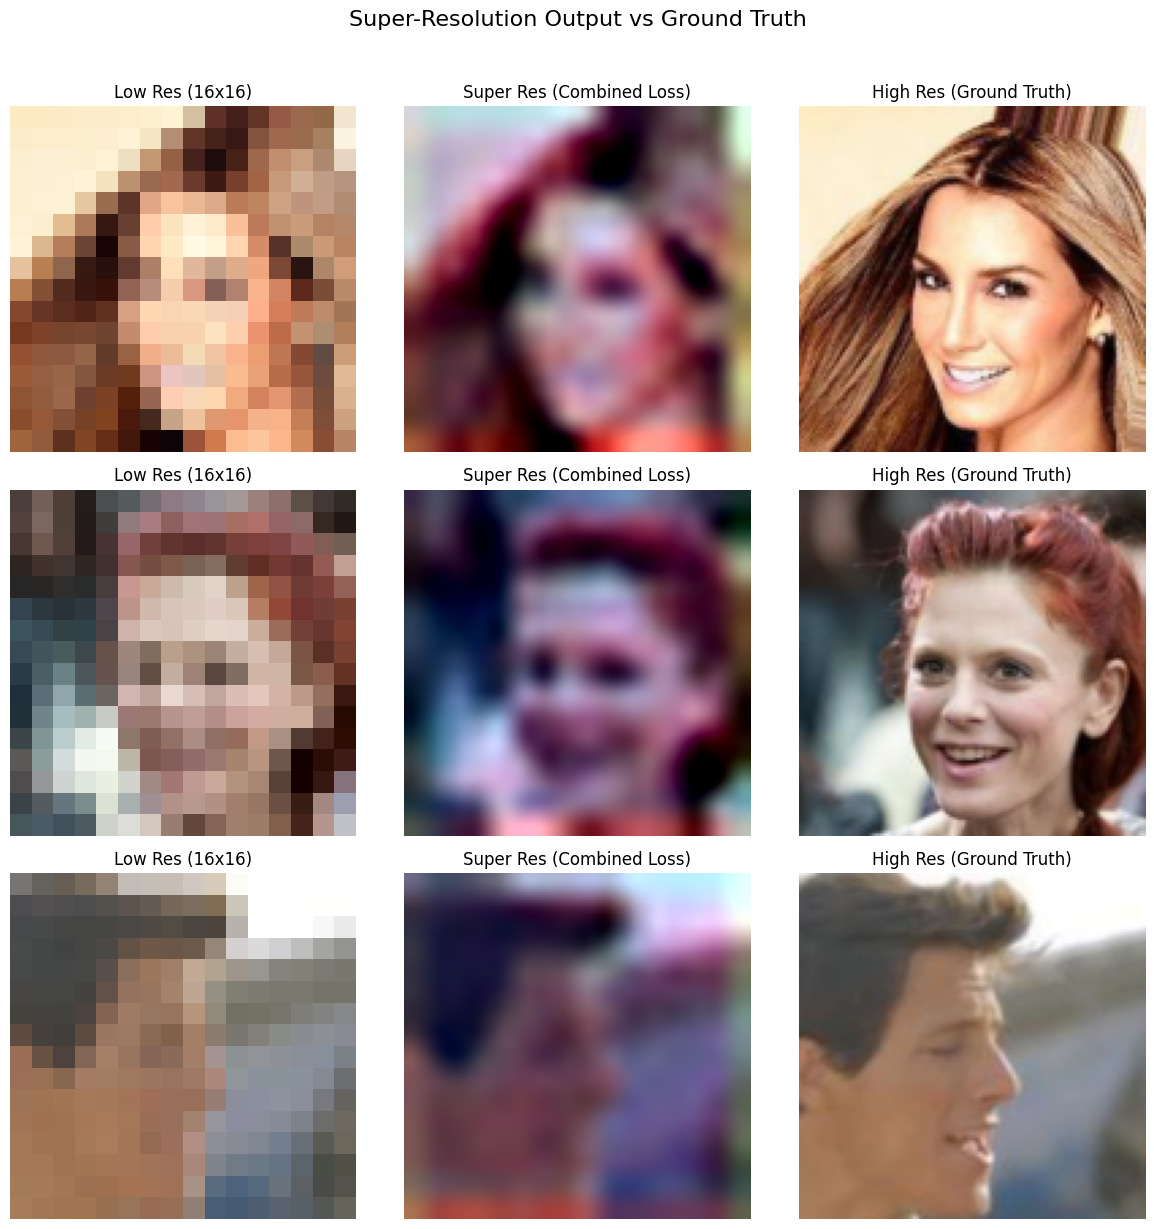

In [ ]:
import matplotlib.pyplot as plt
import torch

# Ensure model is in evaluation mode
model.eval()

# Fetch a batch from the validation loader
lr_imgs, hr_imgs = next(iter(val_loader))
lr_imgs = lr_imgs.to(device)
hr_imgs = hr_imgs.to(device)

# Generate Super-Resolved images
with torch.no_grad():
    sr_imgs = model(lr_imgs)
    # Upsample SR to HR size for proper visual comparison
    sr_imgs_up = F.interpolate(sr_imgs, size=hr_imgs.shape[-2:], mode="bicubic", align_corners=False)

def plot_reconstruction(lr, sr, hr, num_samples=3):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    fig.suptitle("Super-Resolution Output vs Ground Truth", fontsize=16, y=1.02)

    for i in range(num_samples):
        # Clip values to [0, 1] to avoid matplotlib warnings
        axes[i, 0].imshow(lr[i].permute(1, 2, 0).cpu().clamp(0, 1))
        axes[i, 0].set_title("Low Res (16x16)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(sr[i].permute(1, 2, 0).cpu().clamp(0, 1))
        axes[i, 1].set_title("Super Res (Combined Loss)")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(hr[i].permute(1, 2, 0).cpu().clamp(0, 1))
        axes[i, 2].set_title("High Res (Ground Truth)")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# Plot first 3 images in the batch
plot_reconstruction(lr_imgs, sr_imgs_up, hr_imgs, num_samples=3)

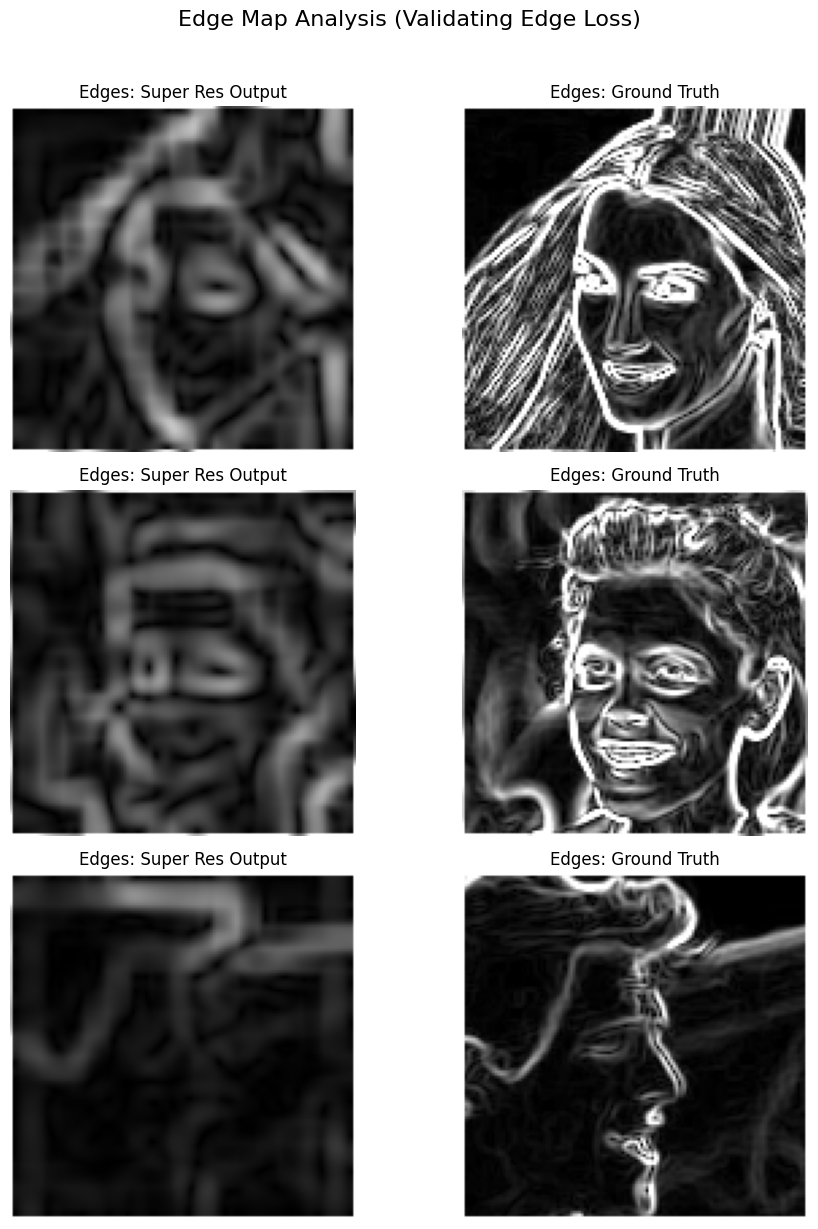

In [ ]:
# Instantiate the Edge Detector from your earlier code
edge_detector = EdgeLoss().to(device)

# Compute edge maps for both the model output and the ground truth
with torch.no_grad():
    sr_edges = edge_detector(sr_imgs_up)
    hr_edges = edge_detector(hr_imgs)

def plot_edges(sr_edges, hr_edges, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    fig.suptitle("Edge Map Analysis (Validating Edge Loss)", fontsize=16, y=1.02)

    for i in range(num_samples):
        # Edge maps are 1-channel, so we squeeze them for grayscale plotting
        sr_edge_img = sr_edges[i].squeeze().cpu().clamp(0, 1)
        hr_edge_img = hr_edges[i].squeeze().cpu().clamp(0, 1)

        axes[i, 0].imshow(sr_edge_img, cmap='gray')
        axes[i, 0].set_title("Edges: Super Res Output")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(hr_edge_img, cmap='gray')
        axes[i, 1].set_title("Edges: Ground Truth")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

# Plot the edge maps for the same 3 images
plot_edges(sr_edges, hr_edges, num_samples=3)

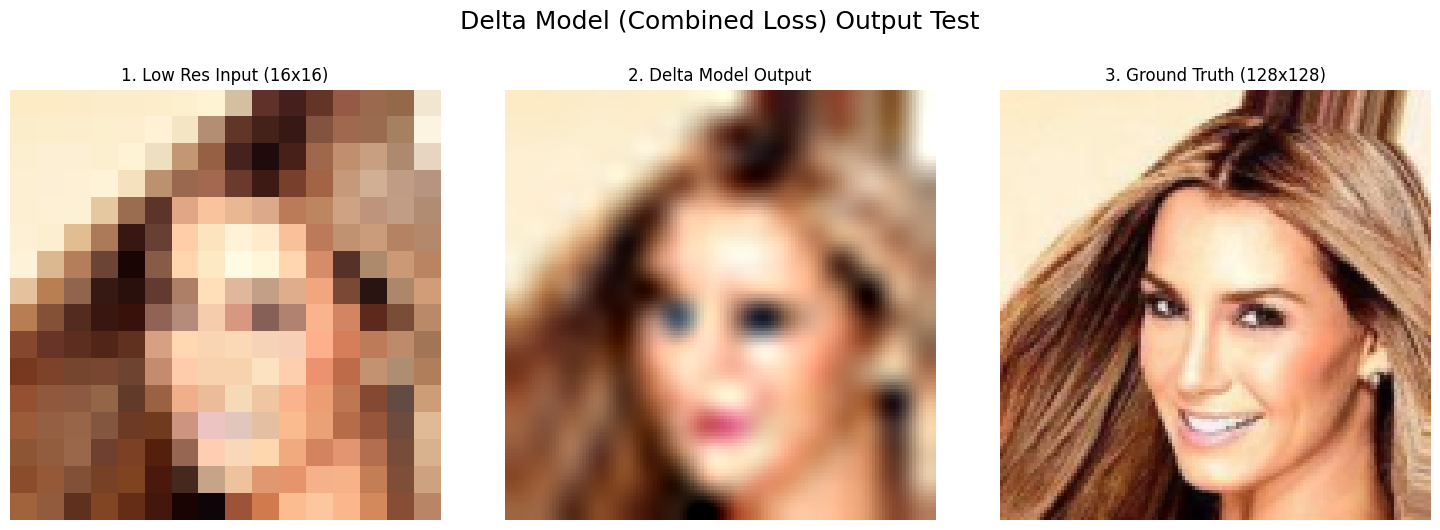

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# 1. Put the delta model in evaluation mode
model_delta.eval()

# 2. Grab a single batch from the validation loader
val_lr, val_hr = next(iter(val_loader))
val_lr = val_lr.to(device)
val_hr = val_hr.to(device)

# 3. Run the model without calculating gradients
with torch.no_grad():
    delta_sr = model_delta(val_lr)
    # Upsample the 16x16 output to 128x128 for a fair visual comparison
    delta_sr_up = F.interpolate(delta_sr, size=val_hr.shape[-2:], mode="bicubic", align_corners=False)

# 4. Function to plot the results
def plot_delta_model_output(lr, sr, hr, index=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Delta Model (Combined Loss) Output Test", fontsize=18, y=1.05)

    # Low Res Input
    axes[0].imshow(lr[index].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[0].set_title("1. Low Res Input (16x16)")
    axes[0].axis("off")

    # Delta Model Output
    axes[1].imshow(sr[index].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[1].set_title("2. Delta Model Output")
    axes[1].axis("off")

    # Ground Truth
    axes[2].imshow(hr[index].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[2].set_title("3. Ground Truth (128x128)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# Plot the first image in the batch (change index to see others)
plot_delta_model_output(val_lr, delta_sr_up, val_hr, index=0)